## Rendimiento y Riesgo 

In [54]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [55]:
tickers = ['NVDA', 'QQQ', 'PLTR', 'DANHOS13.MX', 'GOOG']

In [56]:
prices = yf.download(tickers, start='2020-01-01', end='2026-08-24')["Close"]

/var/folders/x9/60hcc2ln62d3r3xyv90d3wl40000gn/T/ipykernel_53530/4082129560.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(tickers, start='2020-01-01', end='2026-08-24')["Close"]
[*********************100%***********************]  5 of 5 completed


In [57]:
prices

Ticker,DANHOS13.MX,GOOG,NVDA,PLTR,QQQ
Date,,,,,
2020-01-02,17.197742,67.770973,5.963802,NaN,208.088867
2020-01-03,17.109247,67.438416,5.868348,NaN,206.182755
2020-01-06,17.103344,69.101265,5.892957,NaN,207.511230
2020-01-07,17.056149,69.058136,5.964301,NaN,207.482422
2020-01-08,16.867355,69.602356,5.975487,NaN,209.041855
...,...,...,...,...,...
2026-08-17,28.469999,341.450012,225.009995,172.550003,729.869995
2026-08-18,28.260000,341.279999,219.740005,171.539993,717.510010
2026-08-19,28.450001,341.700012,217.559998,175.190002,716.080017


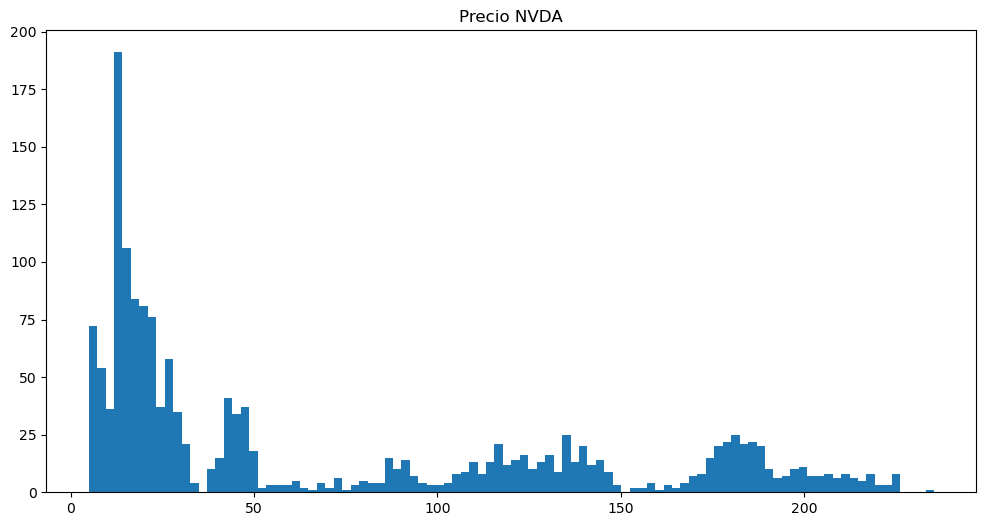

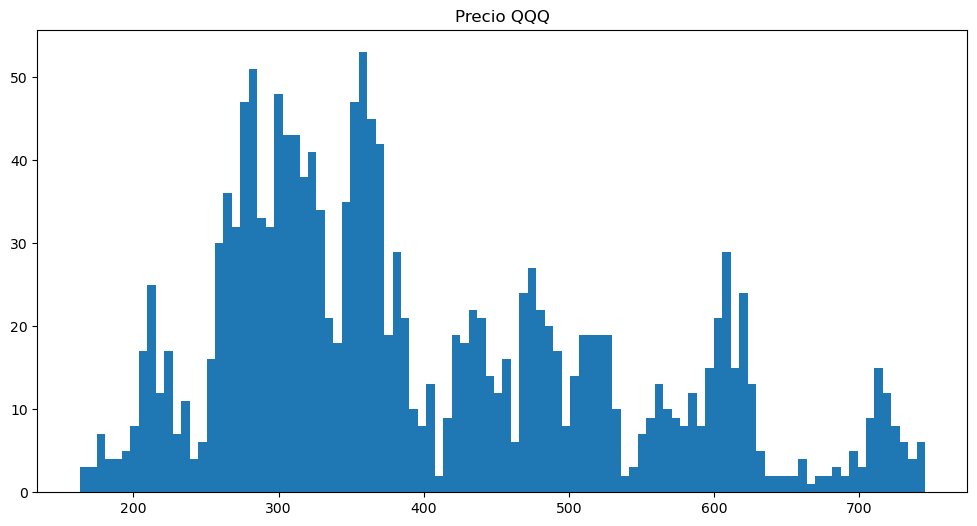

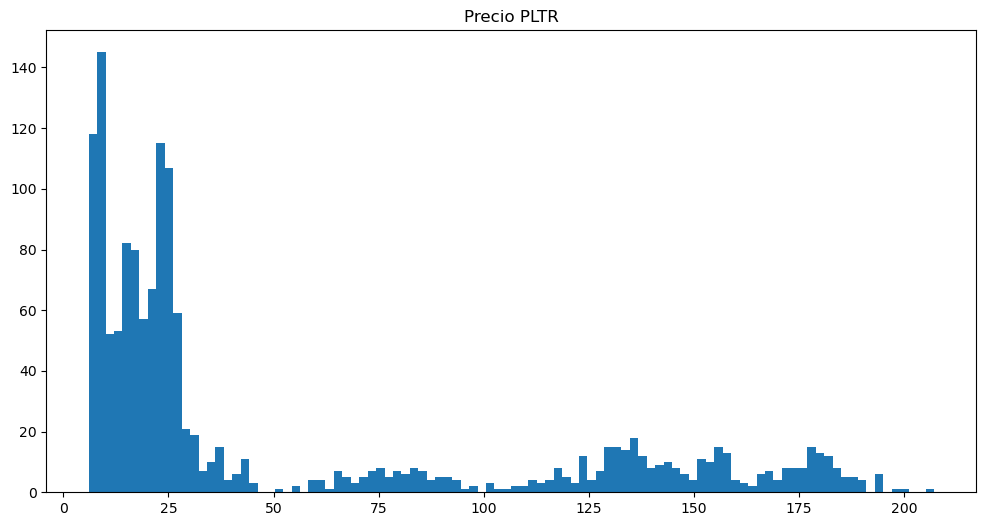

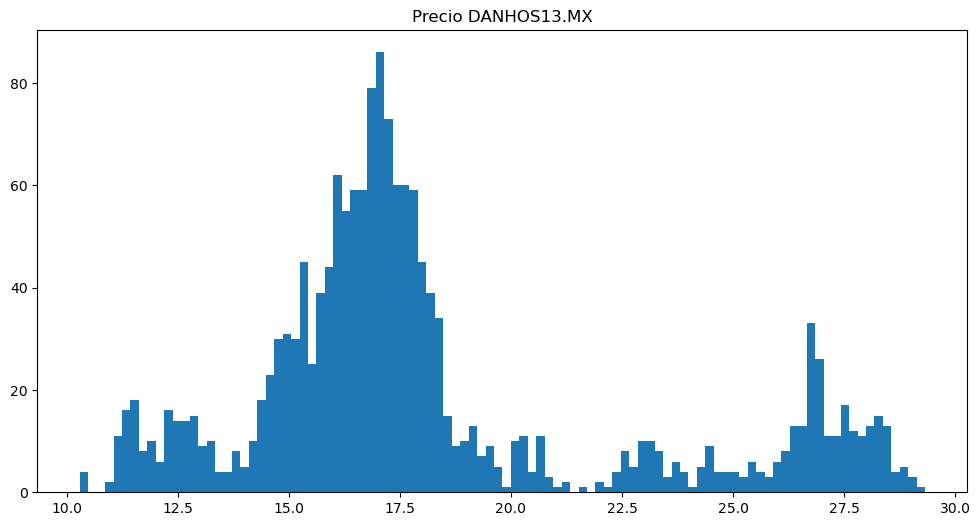

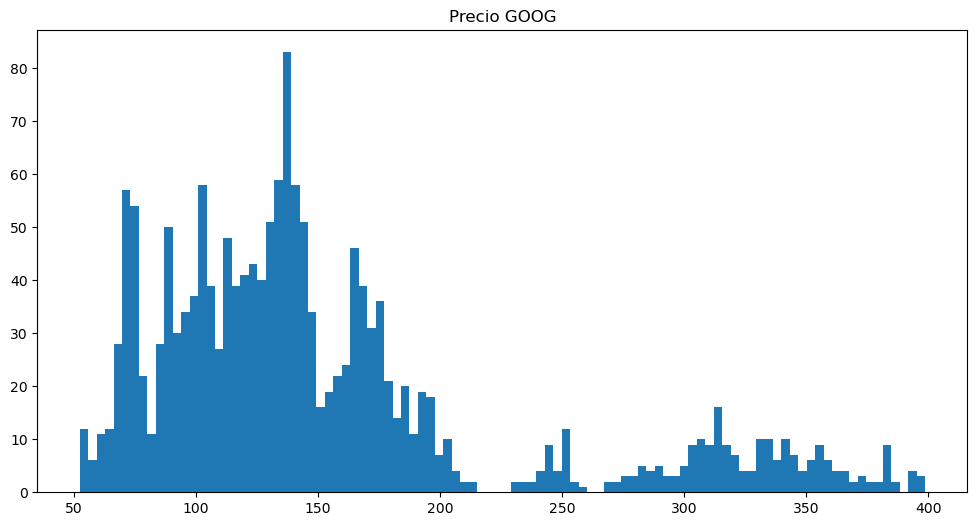

In [58]:
for i in tickers:
    plt.figure(figsize=(12, 6))
    plt.hist(prices[i], bins=100)
    plt.title(f'Precio {i}')
    plt.show(i)

In [59]:
daily_rets=(prices/prices.shift()-1).dropna()
daily_rets

Ticker,DANHOS13.MX,GOOG,NVDA,PLTR,QQQ
Date,,,,,
2020-10-01,-0.024679,0.013943,0.006208,-0.004211,0.015872
2020-10-02,0.026316,-0.021254,-0.040563,-0.027484,-0.028131
2020-10-05,0.012328,0.018925,0.044422,-0.018478,0.021326
2020-10-06,-0.010229,-0.021925,0.006890,0.096346,-0.017847
2020-10-07,0.037401,0.004713,0.016562,0.010101,0.017299
...,...,...,...,...,...
2026-08-17,0.005652,-0.006084,-0.000666,-0.008561,-0.001641
2026-08-18,-0.007376,-0.000498,-0.023421,-0.005853,-0.016935
2026-08-19,0.006723,0.001231,-0.009921,0.021278,-0.001993


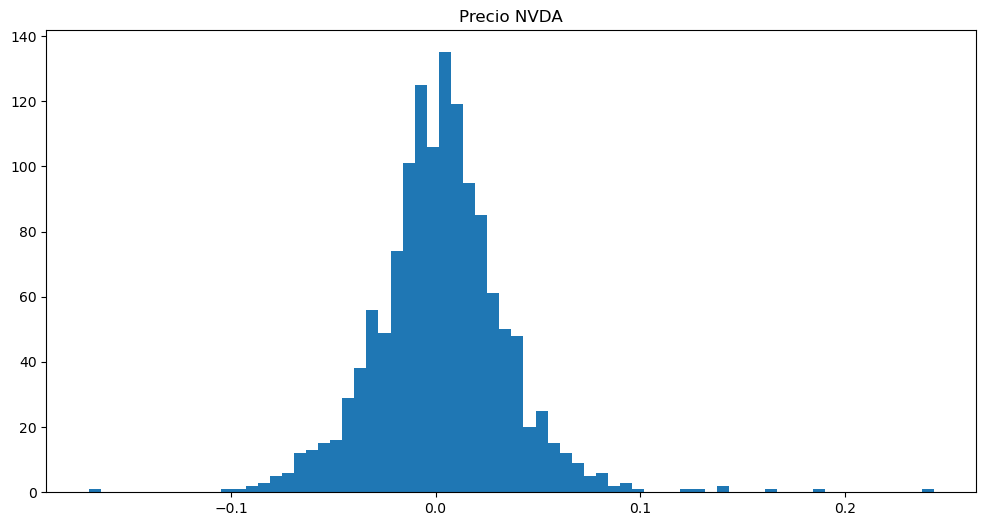

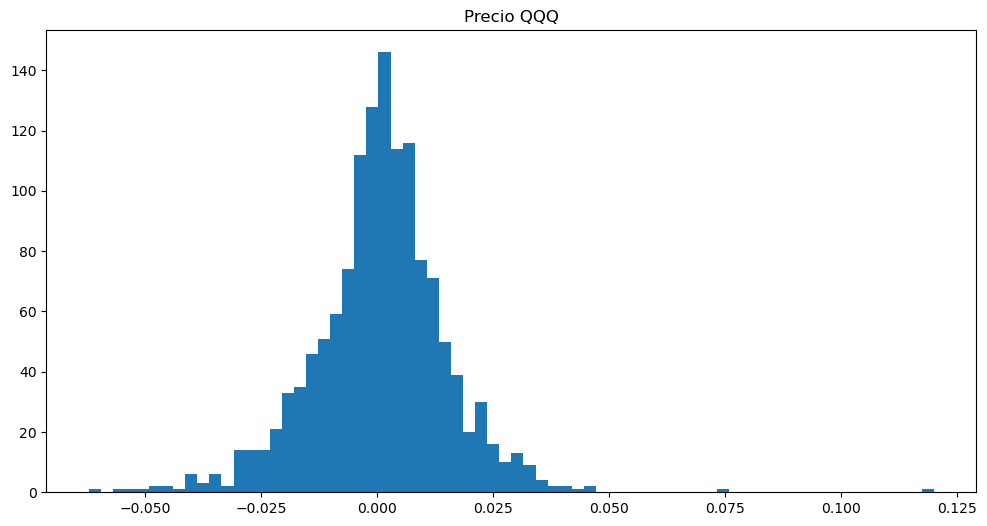

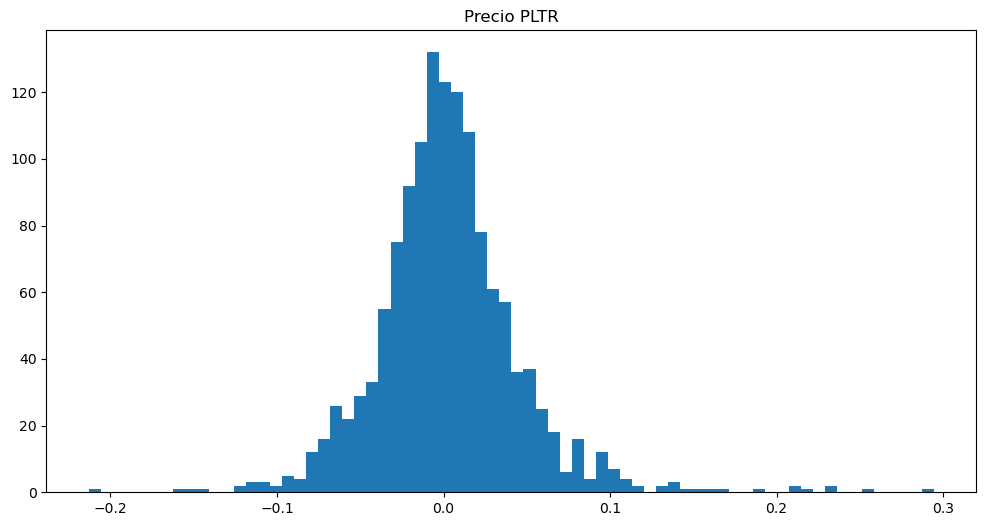

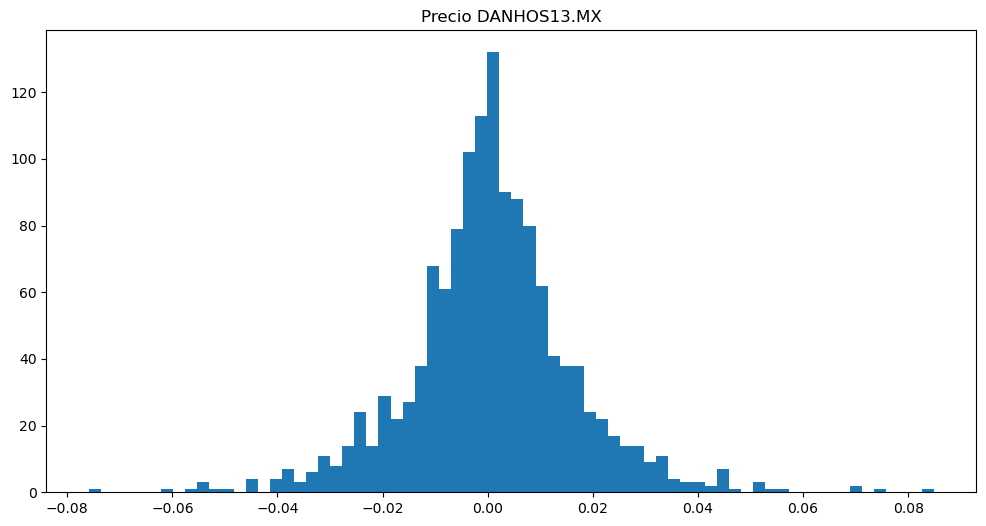

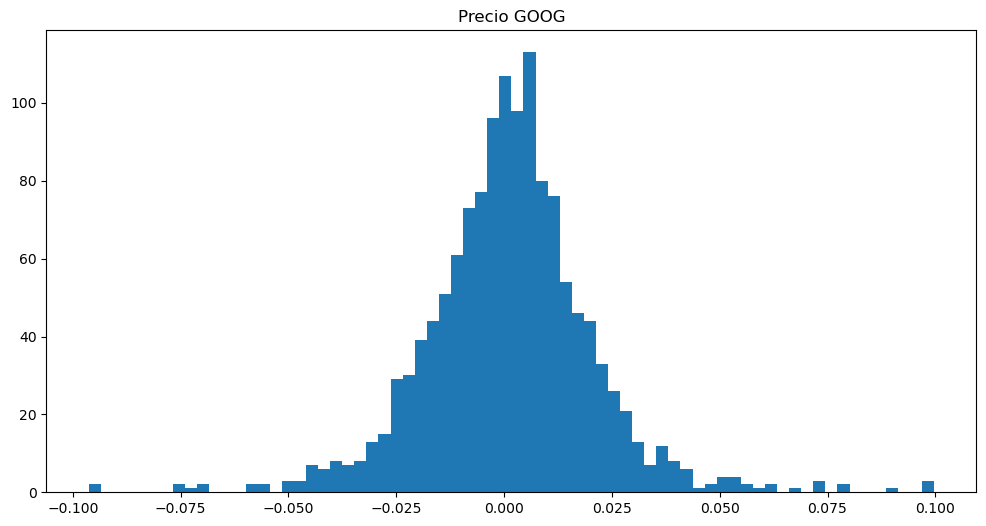

In [60]:
for i in tickers:
    plt.figure(figsize=(12, 6))
    plt.hist(daily_rets[i], bins=70)
    plt.title(f'Precio {i}')
    plt.show();

In [61]:
daily_mean=daily_rets.mean()
daily_mean*100


Ticker
DANHOS13.MX    0.064897
GOOG           0.114677
NVDA           0.248415
PLTR           0.268289
QQQ            0.072793
dtype: float64

In [62]:
annual_mean=daily_mean*252
annual_mean*100

Ticker
DANHOS13.MX    16.354031
GOOG           28.898578
NVDA           62.600570
PLTR           67.608815
QQQ            18.343785
dtype: float64

In [ ]:
daily_variance=daily_rets.var()
#las unidades de la varianza no se pueden interpretar,
#  por lo que se recomienda calcular la desviación estándar, 
# que es la raíz cuadrada de la varianza.
#  La desviación estándar nos da una idea de la dispersión de los datos 
# y se puede interpretar en las mismas unidades que los datos originales.
daily_variance*252*100

Ticker
DANHOS13.MX     6.308253
GOOG            9.728690
NVDA           25.999845
PLTR           47.487764
QQQ             5.216212
dtype: float64

In [ ]:
daily_volatility=daily_rets.std()
daily_volatility*100
#todo este bloque de codigo lo que hace es calcular la volatilidad diaria de cada activo, 
# que es una medida de riesgo. La volatilidad 
# se calcula como la desviación estándar de los rendimientos diarios.
#  Luego, se multiplica por 100 para expresarlo en porcentaje.

Ticker
DANHOS13.MX    1.582174
GOOG           1.964839
NVDA           3.212071
PLTR           4.341008
QQQ            1.438724
dtype: float64

In [65]:
daily_mean-3*volatility_annual*100, annual_mean+3*volatility_annual*100

(Ticker
 DANHOS13.MX    -75.348058
 GOOG           -93.571396
 NVDA          -152.967644
 PLTR          -206.731416
 QQQ            -68.516358
 dtype: float64,
 Ticker
 DANHOS13.MX     75.512247
 GOOG            93.861528
 NVDA           153.596134
 PLTR           207.410187
 QQQ             68.700524
 dtype: float64)

In [66]:
volatility_annual=daily_volatility*np.sqrt(252)
volatility_annual

Ticker
DANHOS13.MX    0.251162
GOOG           0.311908
NVDA           0.509900
PLTR           0.689114
QQQ            0.228390
dtype: float64

In [67]:
CV=volatility_annual/annual_mean
CV
# El mejor es aquel que tenga el menor CV,
#  ya que esto indica que tiene un menor riesgo en relación con su rendimiento esperado.


Ticker
DANHOS13.MX    1.535783
GOOG           1.079321
NVDA           0.814530
PLTR           1.019266
QQQ            1.245055
dtype: float64

In [68]:
volatility_annual,annual_mean

(Ticker
 DANHOS13.MX    0.251162
 GOOG           0.311908
 NVDA           0.509900
 PLTR           0.689114
 QQQ            0.228390
 dtype: float64,
 Ticker
 DANHOS13.MX    0.163540
 GOOG           0.288986
 NVDA           0.626006
 PLTR           0.676088
 QQQ            0.183438
 dtype: float64)

In [69]:
daily_rets.skew()

Ticker
DANHOS13.MX    0.153439
GOOG           0.172822
NVDA           0.532570
PLTR           0.918041
QQQ            0.171463
dtype: float64

.skew() nos puede dar tres posibles valores:  
**1- Skew = 0:** Simetrico (Asimetria=0).   
**2- Skew < 0:** Asimetria negativa - outliers cargados a las pérdidas.   
-(Malo, porque es más probable tener una pérdida atipica y mayor, que una ganancia atipica).   
**3- Skew > 0:** Asimetria positiva - outliers cargados a las ganancias.   
-(Bueno o positivo, porque es más probable un evento atipico positivo)+

OjO= Si podemos saber cual activo es más 

 una distribucion normal tienen 3 momentos , los rendimientos, la volatilidad y la simetria o el sesgo

 en finanzas no trabajamos con precios por si solos
 Valor esperado es media, riesgo es volatilidad 
 varianza  dispersion 